# U-Net for SWAN Synthetic Prestack Multiple Attenuation

This notebook builds a **2-input / 1-output U-Net** for seismic multiple attenuation using the file:

```python
SWAN_syn_prestack_multiple.npz
```

The dataset is assumed to contain:

- `data` with shape **(2, 512, 256, 256)**
- `label` with shape **(1, 512, 256, 256)**

where:

- `data[0, i, :, :]` = **raw prestack data**
- `data[1, i, :, :]` = **optimal multiple model**
- `label[0, i, :, :]` = **ground-truth primary**

The notebook will:

1. Load and inspect the dataset
2. Reorder dimensions into PyTorch format `(N, C, H, W)`
3. Visualize representative samples
4. Split the dataset into training and validation subsets
5. Define a U-Net for image-to-image regression
6. Train the model
7. Validate the model with quantitative metrics
8. Visualize predictions, residuals, and training curves
9. Save the trained model and figures

---

## Learning objective

We want to learn a mapping

$f_\theta(x_{\text{raw}}, x_{\text{multiple}}) \approx y_{\text{primary}}$

where:

- $x_{\text{raw}}$ is the raw seismic input
- $x_{\text{multiple}}$ is the optimal multiple model
- $y_{\text{primary}}$ is the ground-truth primary

The U-Net takes the two input channels together and predicts one output channel.

## Reference

1. Qu, S., Verschuur, E., Zhang, D. and Chen, Y., 2021. Training deep networks with only synthetic data: Deep-learning-based near-offset reconstruction for (closed-loop) surface-related multiple estimation on shallow-water field data. Geophysics, 86(3), pp.A39-A43.
2. Zhang, D., de Leeuw, M. and Verschuur, E., 2021, November. Deep learning-based seismic surface-related multiple adaptive subtraction with synthetic primary labels. In SEG International Exposition and Annual Meeting (p. D011S124R001). SEG.

## 1. Imports and reproducibility

In [1]:
import os
import math
import random
from typing import Tuple, Dict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## 2. Configuration

Update these parameters if you want to change the training behavior.

In [3]:
# Input file
npz_path = "../dataset/SWAN_syn_prestack_multiple.npz"

# Output directory for saved figures and model
output_dir = "outputs_swan_unet"
os.makedirs(output_dir, exist_ok=True)

# Training settings
batch_size = 8
num_epochs = 40
learning_rate = 1e-3
weight_decay = 1e-5
val_ratio = 0.2
num_workers = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 3. Utility functions

These helper functions handle:

- normalization
- metrics
- parameter counting
- directory creation

In [4]:
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def normalize_per_sample(x: np.ndarray, eps: float = 1e-8) -> Tuple[np.ndarray, np.ndarray]:
    '''
    Per-sample max-absolute normalization.

    Input:
        x: shape (N, C, H, W)

    Returns:
        x_norm: normalized array
        scale:  shape (N, 1, 1, 1)
    '''
    scale = np.max(np.abs(x), axis=(1, 2, 3), keepdims=True)
    scale = np.maximum(scale, eps)
    x_norm = x / scale
    return x_norm, scale

def compute_mae(pred: torch.Tensor, target: torch.Tensor) -> float:
    return torch.mean(torch.abs(pred - target)).item()

def compute_rmse(pred: torch.Tensor, target: torch.Tensor) -> float:
    return torch.sqrt(torch.mean((pred - target) ** 2)).item()

def compute_psnr(pred: torch.Tensor, target: torch.Tensor, data_range: float = 2.0) -> float:
    '''
    PSNR for approximately normalized data in [-1, 1].
    '''
    mse = torch.mean((pred - target) ** 2).item()
    if mse <= 1e-12:
        return 99.0
    return 20.0 * math.log10(data_range) - 10.0 * math.log10(mse)

## 4. Load the SWAN dataset

The original shapes are expected to be:

- `data`: `(2, 512, 256, 256)`
- `label`: `(1, 512, 256, 256)`

PyTorch convolutional layers expect the channel dimension to come **after** the batch dimension, so we reorder to:

- `data`: `(512, 2, 256, 256)`
- `label`: `(512, 1, 256, 256)`

In [5]:
def load_swan_npz(npz_path: str) -> Tuple[np.ndarray, np.ndarray]:
    pack = np.load(npz_path)

    if "data" not in pack or "label" not in pack:
        raise KeyError("The npz file must contain keys 'data' and 'label'.")

    data = pack["data"]
    label = pack["label"]

    print("Original data shape :", data.shape)
    print("Original label shape:", label.shape)

    if data.ndim != 4 or label.ndim != 4:
        raise ValueError("Expected 4D arrays for both data and label.")

    # Convert (C, N, H, W) -> (N, C, H, W)
    if data.shape[0] == 2:
        data = np.transpose(data, (1, 0, 2, 3))
    elif data.shape[1] == 2:
        pass
    else:
        raise ValueError(f"Cannot infer channel dimension for data shape {data.shape}")

    if label.shape[0] == 1:
        label = np.transpose(label, (1, 0, 2, 3))
    elif label.shape[1] == 1:
        pass
    else:
        raise ValueError(f"Cannot infer channel dimension for label shape {label.shape}")

    print("Reordered data shape :", data.shape)
    print("Reordered label shape:", label.shape)

    if data.shape[0] != label.shape[0]:
        raise ValueError("Number of samples in data and label does not match.")

    return data.astype(np.float32), label.astype(np.float32)

x, y = load_swan_npz(npz_path)

Original data shape : (2, 512, 256, 256)
Original label shape: (1, 512, 256, 256)
Reordered data shape : (512, 2, 256, 256)
Reordered label shape: (512, 1, 256, 256)


### Optional normalization

Seismic amplitudes can vary a lot from sample to sample. A robust and simple strategy is **per-sample max-absolute normalization**:

\[
x_{\text{norm}} = \frac{x}{\max |x|}
\]

This is done independently for each sample.

In [6]:
x, x_scale = normalize_per_sample(x)
y, y_scale = normalize_per_sample(y)

print("Normalized data range : [{:.4f}, {:.4f}]".format(x.min(), x.max()))
print("Normalized label range: [{:.4f}, {:.4f}]".format(y.min(), y.max()))

Normalized data range : [-0.7978, 1.0000]
Normalized label range: [-0.7642, 1.0000]


## 5. Visualize representative samples

Each sample has:

- channel 0: raw data
- channel 1: optimal multiple model
- label: ground-truth primary

This cell helps verify that the loading and dimension reordering are correct.

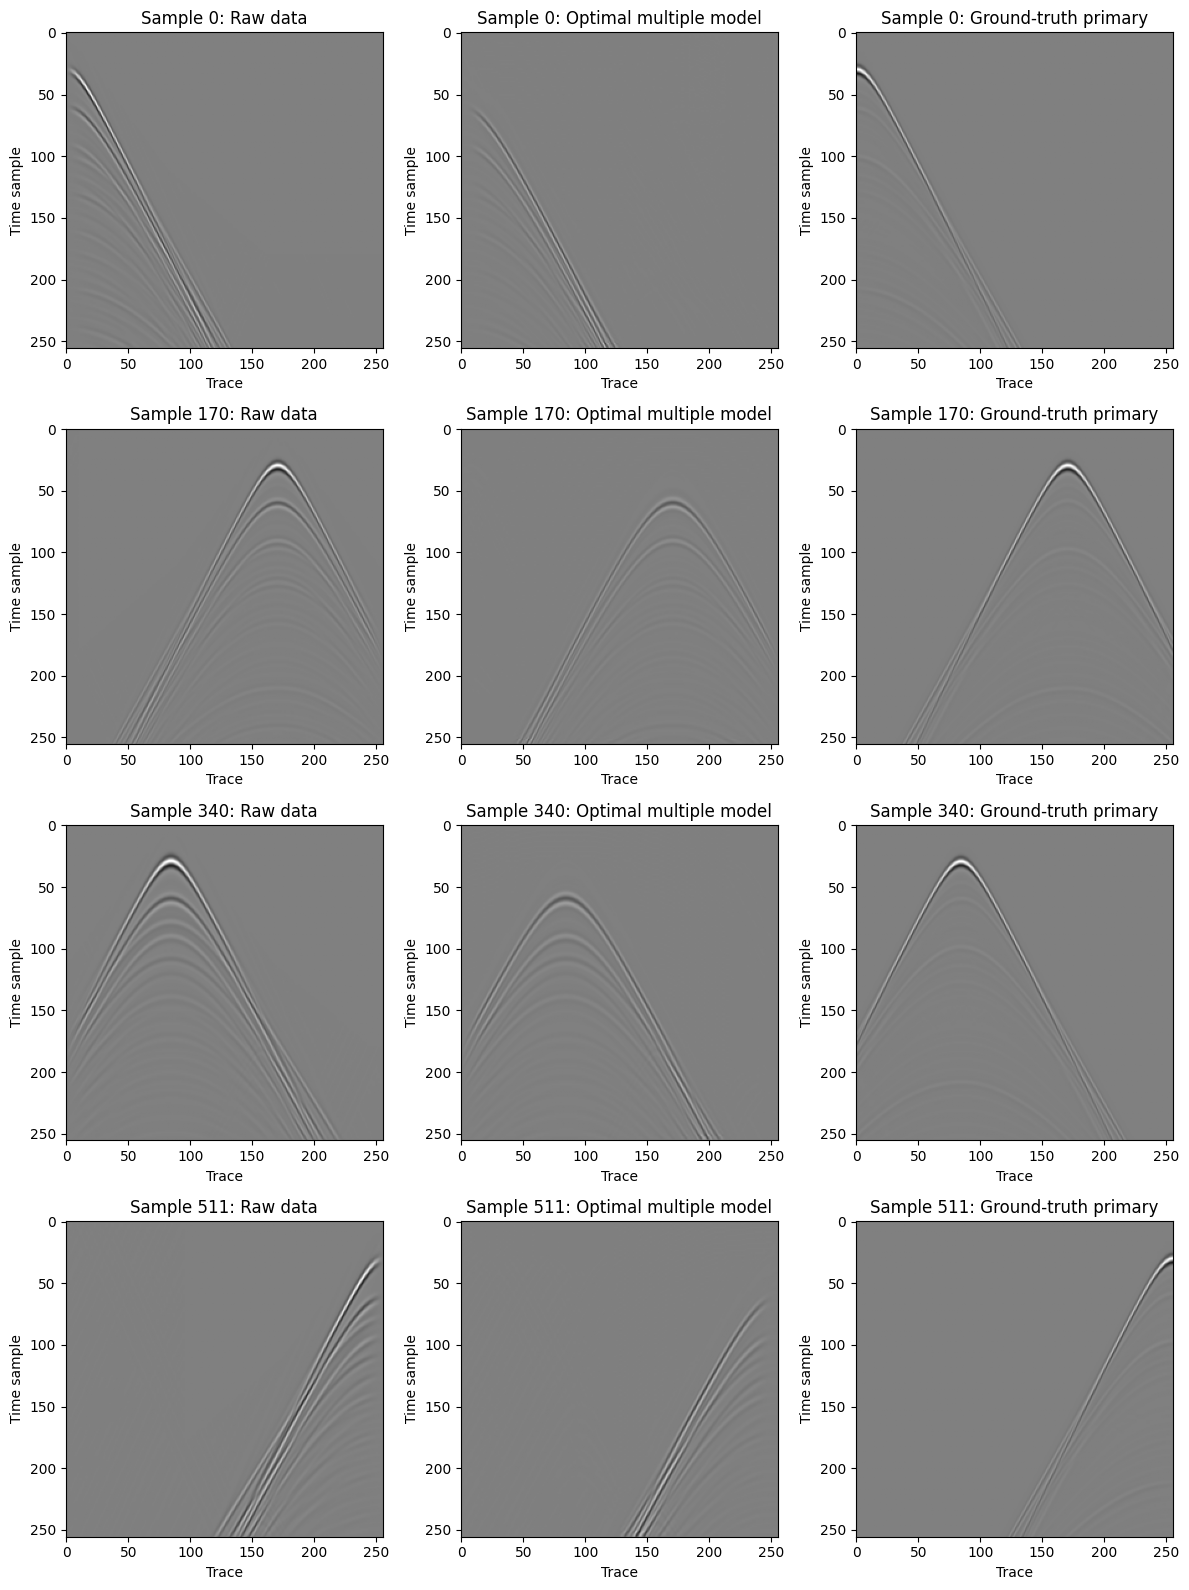

In [7]:
def show_dataset_samples(x: np.ndarray, y: np.ndarray, save_path: str, num_samples: int = 4):
    n = x.shape[0]
    idxs = np.linspace(0, n - 1, num_samples, dtype=int)

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(idxs):
        raw = x[idx, 0]
        mult = x[idx, 1]
        primary = y[idx, 0]

        vmax = max(np.max(np.abs(raw)), np.max(np.abs(mult)), np.max(np.abs(primary)))
        vmax = max(vmax, 1e-6)

        panels = [
            (raw, "Raw data"),
            (mult, "Optimal multiple model"),
            (primary, "Ground-truth primary"),
        ]

        for col, (img, title) in enumerate(panels):
            ax = axes[row, col]
            ax.imshow(img, cmap="gray", aspect="auto", vmin=-vmax, vmax=vmax)
            ax.set_title(f"Sample {idx}: {title}")
            ax.set_xlabel("Trace")
            ax.set_ylabel("Time sample")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

show_dataset_samples(
    x, y,
    save_path=os.path.join(output_dir, "dataset_samples.png"),
    num_samples=4
)

## 6. PyTorch dataset and data loaders

The arrays are converted into PyTorch tensors, then split into training and validation subsets.

In [8]:
class SWANDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.from_numpy(x).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

full_dataset = SWANDataset(x, y)

n_total = len(full_dataset)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

print(f"Total samples: {n_total}")
print(f"Train samples: {n_train}")
print(f"Val samples  : {n_val}")

Total samples: 512
Train samples: 410
Val samples  : 102


## 7. U-Net architecture

We use a standard encoder-decoder U-Net with skip connections.

### Why U-Net here?

This is a natural choice for seismic image-to-image regression because it combines:

- **downsampling** to capture broader spatial context
- **upsampling** to reconstruct fine-scale structures
- **skip connections** to preserve reflector continuity and event details

### Input and output shapes

- input: `(B, 2, 256, 256)`
- output: `(B, 1, 256, 256)`

So the network learns:

\[
f_\theta: \mathbb{R}^{2 \times 256 \times 256} \rightarrow \mathbb{R}^{1 \times 256 \times 256}
\]

In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        self.bilinear = bilinear

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
            self.conv = DoubleConv(in_ch, out_ch)
        else:
            self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diff_y = x2.size()[2] - x1.size()[2]
        diff_x = x2.size()[3] - x1.size()[3]

        x1 = F.pad(
            x1,
            [diff_x // 2, diff_x - diff_x // 2,
             diff_y // 2, diff_y - diff_y // 2]
        )

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1, base_ch=32, bilinear=True):
        super().__init__()

        self.inc = DoubleConv(in_channels, base_ch)
        self.down1 = Down(base_ch, base_ch * 2)
        self.down2 = Down(base_ch * 2, base_ch * 4)
        self.down3 = Down(base_ch * 4, base_ch * 8)
        self.down4 = Down(base_ch * 8, base_ch * 16)

        self.up1 = Up(base_ch * 16 + base_ch * 8, base_ch * 8, bilinear=bilinear)
        self.up2 = Up(base_ch * 8 + base_ch * 4, base_ch * 4, bilinear=bilinear)
        self.up3 = Up(base_ch * 4 + base_ch * 2, base_ch * 2, bilinear=bilinear)
        self.up4 = Up(base_ch * 2 + base_ch, base_ch, bilinear=bilinear)

        self.outc = OutConv(base_ch, out_channels)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        x = self.outc(x)
        return x

## 8. Loss function

We use a hybrid loss:

\[
\mathcal{L} = \alpha \lVert \hat{y} - y \rVert_1 + \beta \lVert \hat{y} - y \rVert_2^2
\]

with:

- \(\alpha = 0.8\)
- \(\beta = 0.2\)

### Why this combination?

- **L1 loss** helps preserve sharper structures
- **MSE loss** strongly penalizes large errors and helps stabilize training

This is often a practical compromise for seismic reconstruction tasks.

In [10]:
class HybridLoss(nn.Module):
    def __init__(self, alpha=0.8, beta=0.2):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.l1 = nn.L1Loss()
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        return self.alpha * self.l1(pred, target) + self.beta * self.mse(pred, target)

## 9. Build the model

This cell initializes:

- the U-Net
- the loss function
- the optimizer
- the learning-rate scheduler

In [11]:
model = UNet(in_channels=2, out_channels=1, base_ch=32, bilinear=True).to(device)
criterion = HybridLoss(alpha=0.8, beta=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

print(model)
print(f"Trainable parameters: {count_parameters(model):,}")

UNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): BatchNorm

## 10. Training and validation functions

The validation stage computes:

- loss
- MAE
- RMSE
- PSNR

These metrics help quantify how well the predicted primary matches the ground-truth label.

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_mae = 0.0
    total_rmse = 0.0
    total_psnr = 0.0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        pred = model(x_batch)
        loss = criterion(pred, y_batch)

        total_loss += loss.item() * x_batch.size(0)
        total_mae += torch.mean(torch.abs(pred - y_batch), dim=(1, 2, 3)).sum().item()
        total_rmse += torch.sqrt(torch.mean((pred - y_batch) ** 2, dim=(1, 2, 3))).sum().item()

        for i in range(x_batch.size(0)):
            total_psnr += compute_psnr(pred[i], y_batch[i], data_range=2.0)

    n = len(loader.dataset)
    return {
        "loss": total_loss / n,
        "mae": total_mae / n,
        "rmse": total_rmse / n,
        "psnr": total_psnr / n,
    }

## 11. Train the model

This cell performs the full training loop and saves the best validation model to disk.

In [13]:
history = {
    "train_loss": [],
    "val_loss": [],
    "val_mae": [],
    "val_rmse": [],
    "val_psnr": [],
}

best_val_loss = float("inf")
best_model_path = os.path.join(output_dir, "best_unet_model.pth")

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_stats = validate(model, val_loader, criterion, device)

    scheduler.step(val_stats["loss"])

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_stats["loss"])
    history["val_mae"].append(val_stats["mae"])
    history["val_rmse"].append(val_stats["rmse"])
    history["val_psnr"].append(val_stats["psnr"])

    print(
        f"Epoch [{epoch:03d}/{num_epochs:03d}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_stats['loss']:.6f} | "
        f"Val MAE: {val_stats['mae']:.6f} | "
        f"Val RMSE: {val_stats['rmse']:.6f} | "
        f"Val PSNR: {val_stats['psnr']:.2f} dB"
    )

    if val_stats["loss"] < best_val_loss:
        best_val_loss = val_stats["loss"]
        torch.save(model.state_dict(), best_model_path)
        print(f"  -> Best model saved to {best_model_path}")

Epoch [001/040] | Train Loss: 0.019394 | Val Loss: 0.009162 | Val MAE: 0.011079 | Val RMSE: 0.038505 | Val PSNR: 34.35 dB
  -> Best model saved to outputs_swan_unet/best_unet_model.pth
Epoch [002/040] | Train Loss: 0.006560 | Val Loss: 0.005873 | Val MAE: 0.007199 | Val RMSE: 0.023556 | Val PSNR: 38.70 dB
  -> Best model saved to outputs_swan_unet/best_unet_model.pth
Epoch [003/040] | Train Loss: 0.005702 | Val Loss: 0.005452 | Val MAE: 0.006706 | Val RMSE: 0.020065 | Val PSNR: 40.34 dB
  -> Best model saved to outputs_swan_unet/best_unet_model.pth
Epoch [004/040] | Train Loss: 0.005390 | Val Loss: 0.004702 | Val MAE: 0.005771 | Val RMSE: 0.019791 | Val PSNR: 40.47 dB
  -> Best model saved to outputs_swan_unet/best_unet_model.pth
Epoch [005/040] | Train Loss: 0.005295 | Val Loss: 0.004579 | Val MAE: 0.005616 | Val RMSE: 0.019992 | Val PSNR: 40.36 dB
  -> Best model saved to outputs_swan_unet/best_unet_model.pth
Epoch [006/040] | Train Loss: 0.004896 | Val Loss: 0.004188 | Val MAE: 0.00

## 12. Plot training curves

These figures help diagnose learning behavior.

A healthy training run often shows:

- decreasing training loss
- decreasing validation loss
- improving validation MAE / RMSE / PSNR

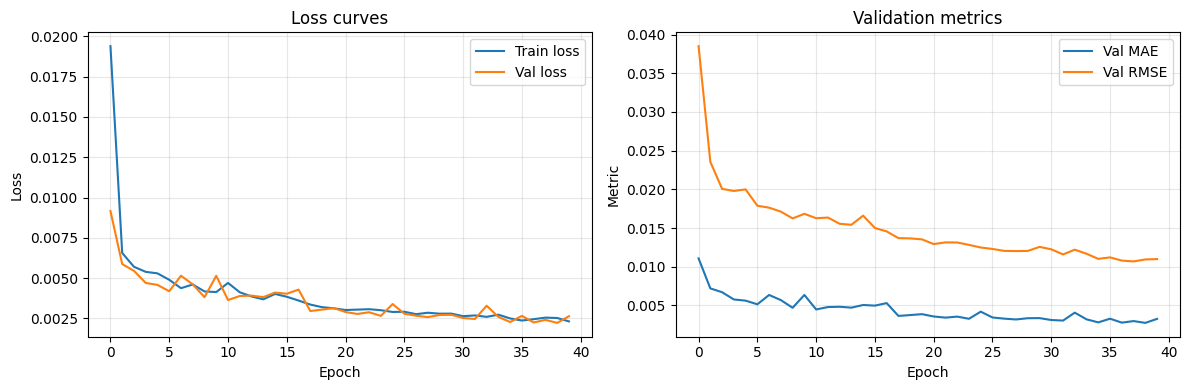

In [14]:
def plot_training_curves(history: Dict[str, list], save_path: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="Train loss")
    axes[0].plot(history["val_loss"], label="Val loss")
    axes[0].set_title("Loss curves")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history["val_mae"], label="Val MAE")
    axes[1].plot(history["val_rmse"], label="Val RMSE")
    axes[1].set_title("Validation metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Metric")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_training_curves(
    history,
    save_path=os.path.join(output_dir, "training_curves.png")
)

## 13. Reload the best model and report final validation metrics

In [15]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

final_val = validate(model, val_loader, criterion, device)

print("Final best-model validation metrics:")
print(f"  Val Loss : {final_val['loss']:.6f}")
print(f"  Val MAE  : {final_val['mae']:.6f}")
print(f"  Val RMSE : {final_val['rmse']:.6f}")
print(f"  Val PSNR : {final_val['psnr']:.2f} dB")

Final best-model validation metrics:
  Val Loss : 0.002222
  Val MAE  : 0.002742
  Val RMSE : 0.010939
  Val PSNR : 46.01 dB


## 14. Visualize validation predictions

For each selected validation sample, we show:

1. raw input
2. optimal multiple model
3. ground-truth primary
4. predicted primary
5. residual: `GT - prediction`

### Interpretation

A good model should produce:

- a predicted primary close to the label
- a residual image with weak coherent structures
- reduced multiple contamination in the prediction

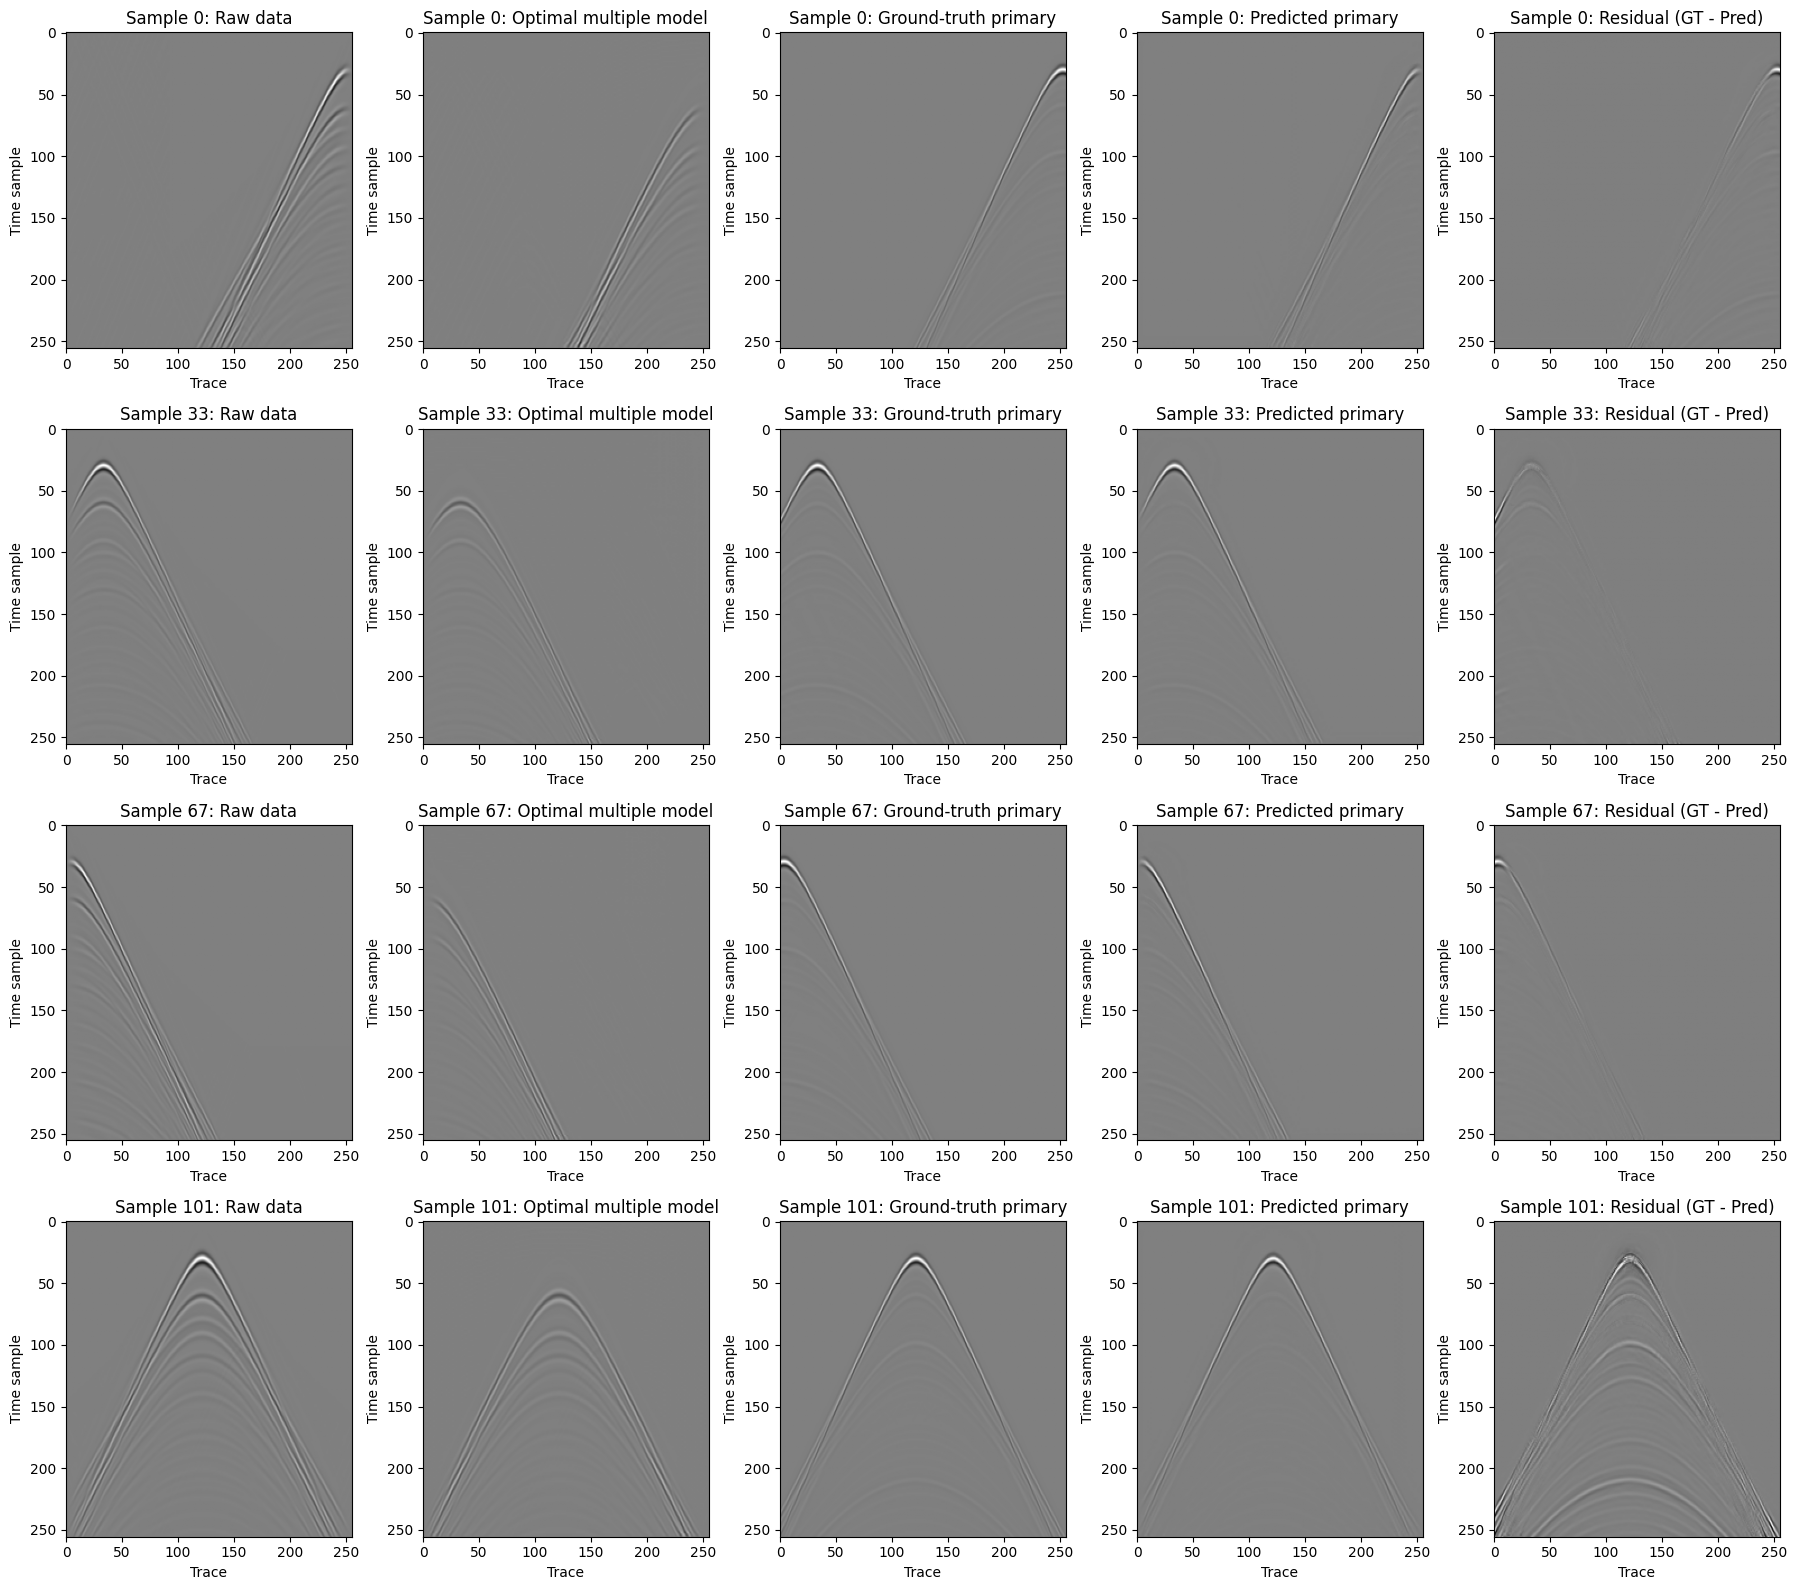

In [16]:
def show_predictions(model: nn.Module, dataset, device, save_path: str, num_samples: int = 4):
    model.eval()

    idxs = np.linspace(0, len(dataset) - 1, num_samples, dtype=int)
    fig, axes = plt.subplots(num_samples, 5, figsize=(18, 4 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for row, idx in enumerate(idxs):
            x_item, y_item = dataset[idx]
            x_in = x_item.unsqueeze(0).to(device)
            pred = model(x_in).cpu().squeeze(0).numpy()

            raw = x_item[0].numpy()
            mult = x_item[1].numpy()
            gt = y_item[0].numpy()
            pr = pred[0]
            err = gt - pr

            vmax = max(
                np.max(np.abs(raw)),
                np.max(np.abs(mult)),
                np.max(np.abs(gt)),
                np.max(np.abs(pr))
            )
            vmax = max(vmax, 1e-6)
            emax = max(np.max(np.abs(err)), 1e-6)

            items = [
                (raw,  "Raw data",               -vmax, vmax),
                (mult, "Optimal multiple model", -vmax, vmax),
                (gt,   "Ground-truth primary",   -vmax, vmax),
                (pr,   "Predicted primary",      -vmax, vmax),
                (err,  "Residual (GT - Pred)",   -emax, emax),
            ]

            for col, (img, title, vmin, vmax_) in enumerate(items):
                ax = axes[row, col]
                ax.imshow(img, cmap="gray", aspect="auto", vmin=vmin, vmax=vmax_)
                ax.set_title(f"Sample {idx}: {title}")
                ax.set_xlabel("Trace")
                ax.set_ylabel("Time sample")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

show_predictions(
    model,
    val_dataset,
    device,
    save_path=os.path.join(output_dir, "validation_predictions.png"),
    num_samples=4
)